In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os


In [7]:
DATA_PATH = "/content/drive/MyDrive/datasets/store_sales"


In [8]:
train = pd.read_csv(f"{DATA_PATH}/train.csv")
stores = pd.read_csv(f"{DATA_PATH}/stores.csv")
oil = pd.read_csv(f"{DATA_PATH}/oil.csv")
holidays = pd.read_csv(f"{DATA_PATH}/holidays_events.csv")
transactions = pd.read_csv(f"{DATA_PATH}/transactions.csv")


In [9]:
train.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [10]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [11]:
train.describe()


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [12]:
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
transactions['date'] = pd.to_datetime(transactions['date'])


In [13]:
train.dtypes


,0
id,int64
date,datetime64[ns]
store_nbr,int64
family,object
sales,float64
onpromotion,int64


In [14]:
train.isnull().sum()


,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


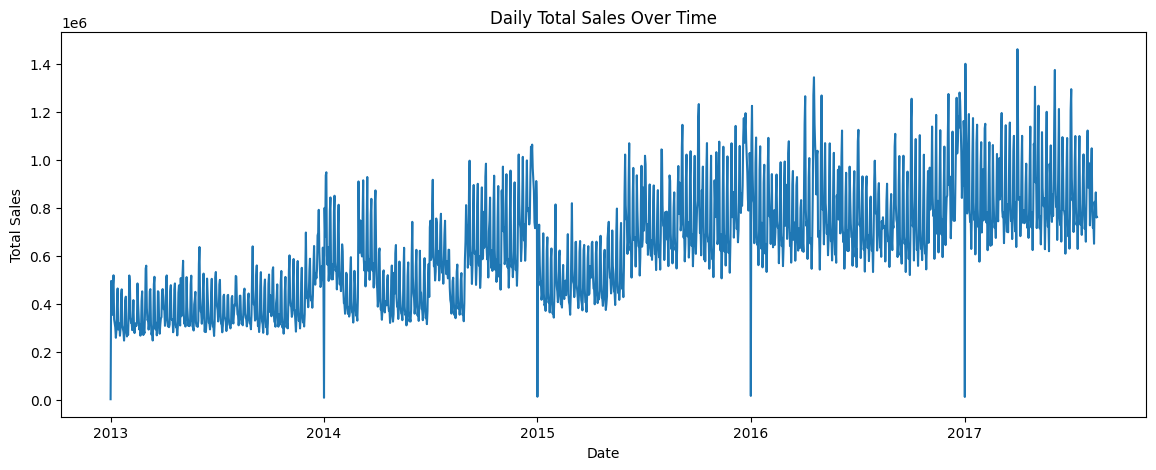

In [16]:
daily_sales = (
    train
    .groupby('date')['sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,5))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


In [18]:
store_sales = (
    train
    .groupby('store_nbr')['sales']
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)


,sales
store_nbr,
44,6.208755e+07
45,5.449801e+07
47,5.094831e+07
3,5.048191e+07
49,4.342010e+07
46,4.189606e+07
48,3.593313e+07
51,3.291149e+07
8,3.049429e+07


In [19]:
family_sales = (
    train
    .groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
)

family_sales.head(10)


,sales
family,
GROCERY I,3.434627e+08
BEVERAGES,2.169545e+08
PRODUCE,1.227047e+08
CLEANING,9.752129e+07
DAIRY,6.448771e+07
BREAD/BAKERY,4.213395e+07
POULTRY,3.187600e+07
MEATS,3.108647e+07
PERSONAL CARE,2.459205e+07


In [20]:
promo_sales = (
    train
    .groupby('onpromotion')['sales']
    .mean()
)

promo_sales


,sales
onpromotion,
0,158.246681
1,467.556532
2,662.925632
3,871.408092
4,969.916135
...,...
719,6681.000000
720,6154.000000
722,5846.000000


## EDA Özeti

- Satış verileri zaman içerisinde belirgin trend ve mevsimsellik göstermektedir.
- Mağazalar ve ürün aileleri arasında satışlar açısından anlamlı farklılıklar bulunmaktadır.
- Promosyon uygulamalarının (`onpromotion`) satışlar üzerinde belirgin bir etkisi olduğu gözlemlenmiştir.
- Bu bulgular, dışsal değişkenleri de içeren zaman serisi ve makine öğrenmesi modellerinin kullanılmasını gerekli kılmaktadır.
